## Figure 1-Style Multi-Strategy Analysis
This notebook reproduces Figure 1-style analyses from the paper using the dataset in `config.py`.

You do not need to edit notebook code. Update `data_path` in `config.py` to point to your own `.csv`.




In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from Functions.standardize_dataset import standardize_dataset
from Functions.set_Beta_prior import set_priors
from Functions.update_strategy_posterior_probability import update_strategy_posterior_probability
from Functions.Summaries_of_Beta_distribution import summaries_of_Beta_Distribution
from Functions.plotSessionStructure import plotSessionStructure
from Functions.interpolate_null_trials import interpolate_null_trials

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import strategymodels

from config import data_path, prior_type, decay_rate, save_output_csv, strategy_name

# Load the exact dataset selected by the user in config.py
TestData = pd.read_csv(data_path)
TestData = standardize_dataset(TestData)
no_Trials = len(TestData)

print(f"Active dataset: {data_path}")
print(f"Trials loaded: {no_Trials}")
TestData.head()

Active dataset: /Users/cerenkimyonok/Desktop/deneme/fare5001.csv
Trials loaded: 734


,TrialIndex,SessionIndex,TargetRule,Choice,CuePosition,Reward,RuleChangeTrials,NewSessionTrials
0,1,1,go right,right,left,yes,0,0
1,2,1,go right,right,right,yes,0,0
2,3,1,go right,left,left,no,0,0
3,4,1,go right,right,right,yes,0,0
4,5,1,go right,left,left,no,0,0


In [2]:

# Strategies shown in Figure 1
strategies = [
    "go_left",
    "go_right",
    "go_cued",
    "win_stay_spatial",
    "lose_shift_cued",
    "lose_shift_spatial"
]


alpha0, beta0 = set_priors(prior_type) 


In [3]:
# Collect strategy functions once
strategy_functions = {}

for strategy in strategies:
    try:
        strategy_functions[strategy] = getattr(strategymodels, strategy)
    except AttributeError:
        raise ValueError(f"Strategy '{strategy}' not found in strategymodels.")

In [4]:
# Initialise storage

Output_collection = {}
event_totals = {}

for strategy in strategies:
    
    Output_collection[strategy] = pd.DataFrame(
        columns=[
            "Alpha", "Beta",
            "MAPprobability", "Precision",
            "Alpha_interpolated", "Beta_interpolated",
            "MAPprobability_interpolated", "Precision_interpolated"
        ]
    )
    
    event_totals[strategy] = {
        "success_total": 0,
        "failure_total": 0
    }

In [5]:
# Run Bayesian strategy analysis across trials

for trial in range(len(TestData)):

    rows_of_data = TestData.iloc[0:trial+1]

    for strategy in strategies:

        strategy_fcn = strategy_functions[strategy]
        trial_type = strategy_fcn(rows_of_data)

        success_total, failure_total, Alpha, Beta = update_strategy_posterior_probability(
            trial_type,
            decay_rate,
            event_totals[strategy]["success_total"],
            event_totals[strategy]["failure_total"],
            alpha0,
            beta0
        )

        event_totals[strategy]["success_total"] = success_total
        event_totals[strategy]["failure_total"] = failure_total

        MAPprobability = summaries_of_Beta_Distribution(Alpha, Beta, "MAP")
        precision = summaries_of_Beta_Distribution(Alpha, Beta, "precision")

        this_trials_data = {
            "Alpha": Alpha,
            "Beta": Beta,
            "MAPprobability": MAPprobability,
            "Precision": precision
        }

        if trial > 0:
            previous_trials_data = Output_collection[strategy].iloc[trial-1]
        else:
            previous_trials_data = Output_collection[strategy]

# -------------------------------------------------------------
# INTERPOLATION STEP (promised in Notebook 1)
# -------------------------------------------------------------
# If a strategy is not directly observed on this trial,
# interpolate_null_trials() carries forward the previous
# posterior information in a controlled way.
#
# This prevents abrupt drops in MAP probability for
# strategies that are temporarily unobserved.
#
# The function generates:
#   - Alpha_interpolated
#   - Beta_interpolated
#   - MAPprobability_interpolated
#   - Precision_interpolated
#
# Note:
#   - Rule-strategy plots use raw MAPprobability.
#   - Exploratory-strategy plots use MAPprobability_interpolated.
# -------------------------------------------------------------

        new_row_of_data = interpolate_null_trials(
            this_trials_data,
            previous_trials_data,
            alpha0,
            beta0
        )

        Output_collection[strategy] = pd.concat(
            [Output_collection[strategy], pd.DataFrame([new_row_of_data])],
            ignore_index=True
        )

/var/folders/1p/18jwl7x13xdgtw3zwr3q9zfr0000gn/T/ipykernel_48107/29408909.py:67: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Output_collection[strategy] = pd.concat(


## Figure 1d- Rule Strategies (MAP Probability)
This panel shows how the model’s belief in each rule-based strategy 
changes across trials.

Each line represents a different strategy:
- Go Left
- Go Right
- Go Cued

The y-axis shows the MAP probability (0–1), which represents 
how strongly the model believes that a strategy is being used.

If one strategy rises above 0.5 and stays high while others decrease,
this suggests that the animal has adopted that strategy.

### Interpolation note (promised in Notebook 1)
In the trial loop, `interpolate_null_trials(...)` creates interpolated values when a strategy is not directly observed on a given trial.

How this affects plots:
- Rule-strategy plot uses raw `MAPprobability` (no interpolation).
- Exploratory-strategy plot uses `MAPprobability_interpolated` so traces remain interpretable across null trials.


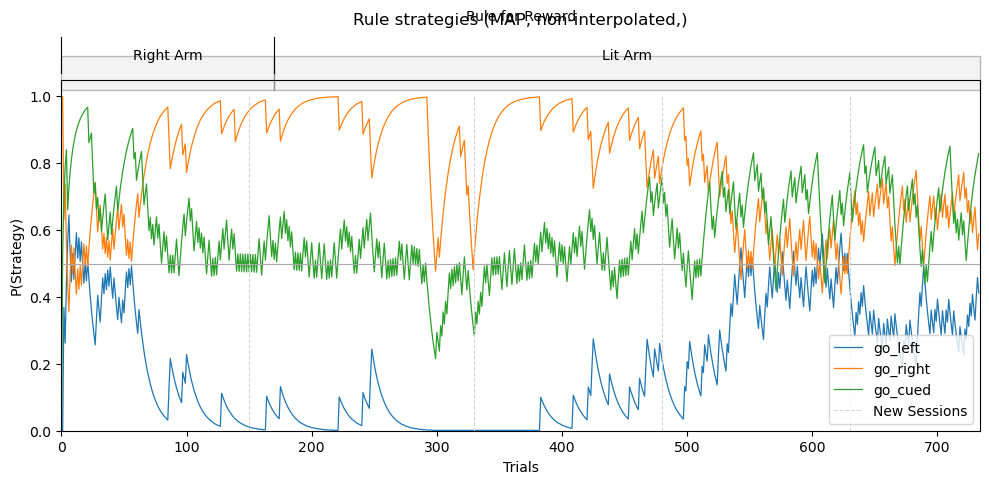

In [6]:
rule_strategies = ["go_left", "go_right", "go_cued"]

# Figure 1d uses non-interpolated MAP for rule strategies.
# Interpolation is computed in the trial loop but intentionally not used here.
plt.figure(figsize=(10, 5))
for s in rule_strategies:
    plt.plot(Output_collection[s]["MAPprobability"], linewidth=0.9, label=s)

plt.axhline(0.5, color="darkgrey", linewidth=0.8)
plt.xlim(0, no_Trials)
plt.ylim(0, 1.05)
plt.xlabel("Trials")
plt.ylabel("P(Strategy)")
plt.title("Rule strategies (MAP, non-interpolated,)", pad=40)
try:
    plotSessionStructure(TestData)
except Exception:
    pass
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# -------- Dynamic Observation --------

final_MAPs = {s: Output_collection[s]["MAPprobability"].iloc[-1]
              for s in rule_strategies}

dominant_rule = max(final_MAPs, key=final_MAPs.get)

print("\n--- Automatic Session Summary ---")
print("Final MAP values:", final_MAPs)
print("Dominant rule strategy:", dominant_rule)

# First crossing above chance
chance = 0.5
MAP_dom = Output_collection[dominant_rule]["MAPprobability"].values
crossings = np.where(MAP_dom > chance)[0]

if len(crossings) > 0:
    first_cross = crossings[0]
    print(f"{dominant_rule} first exceeded chance at trial {first_cross}.")
else:
    print("No rule strategy exceeded chance level.")


--- Automatic Session Summary ---
Final MAP values: {'go_left': np.float64(0.41200000000000003), 'go_right': np.float64(0.588), 'go_cued': np.float64(0.8290000000000001)}
Dominant rule strategy: go_cued
go_cued first exceeded chance at trial 1.


## Figure 1e – Posterior Precision

This panel shows the precision of the posterior distribution 
for selected strategies.

Precision reflects how confident the model is about its belief.

- Low precision → high uncertainty
- High precision → strong confidence

If precision increases while MAP probability stabilises,
this suggests that learning has become robust.

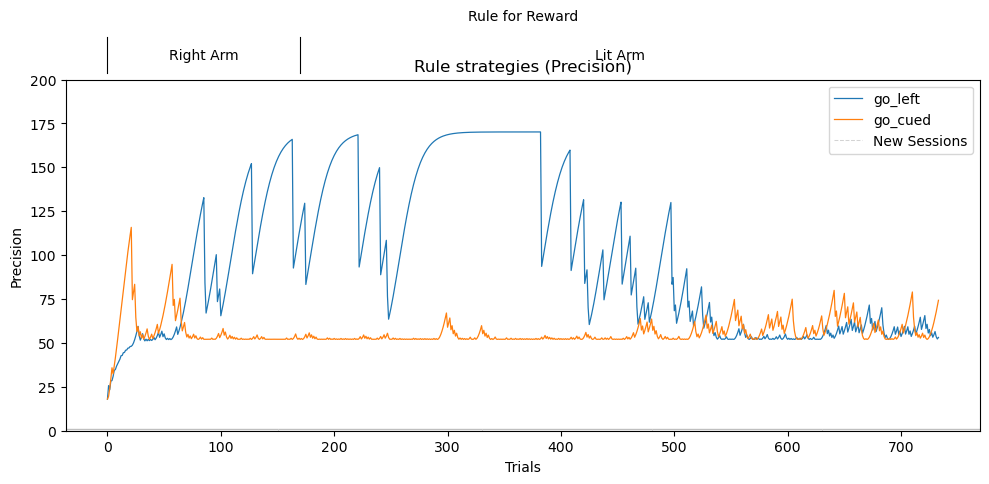

In [8]:
plt.figure(figsize=(10, 5))

for s in ["go_left", "go_cued"]:
    plt.plot(Output_collection[s]["Precision"], linewidth=0.9, label=s)

plt.xlabel("Trials")
plt.ylabel("Precision")
plt.title("Rule strategies (Precision)")

try:
    plotSessionStructure(TestData)
except Exception:
    pass

# 👇 BU SATIRI EKLE
plt.ylim(0, 200)

plt.legend()
plt.tight_layout()
plt.show()

## Figure 1f – Exploratory Strategies

This panel shows exploratory strategies such as:
- Win-Stay
- Lose-Shift (Spatial or Cued)

These strategies describe how the animal responds to trial outcomes: repeating, shifting, or ignoring.

An exploratory strategy can remain high even after the rule is learned. For example, "win_stay_spatial" can stay high during the "go_right" rule because the animal is both choosing the rewarded right arm and applying win-stay to its spatial choice each time it repeats that choice.

What these exploratory strategies tell us is which aspect of the task the animal is paying attention to: the cue, the side, or something else.

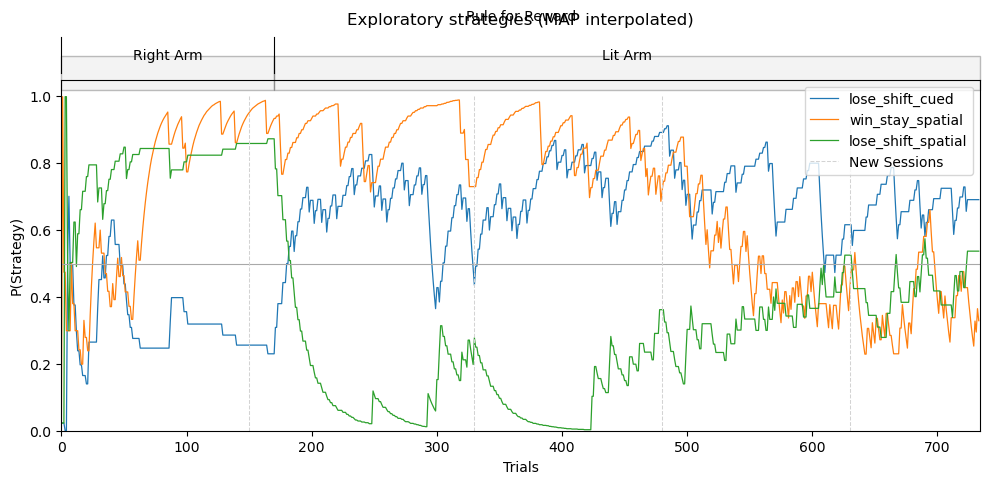

In [9]:
explore_strategies = ["lose_shift_cued", "win_stay_spatial", "lose_shift_spatial"]

plt.figure(figsize=(10, 5))
for s in explore_strategies:
    plt.plot(Output_collection[s]["MAPprobability_interpolated"], linewidth=0.9, label=s)

plt.axhline(0.5, color="darkgrey", linewidth=0.8)
plt.xlim(0, no_Trials)
plt.ylim(0, 1.05)
plt.xlabel("Trials")
plt.ylabel("P(Strategy)")
plt.title("Exploratory strategies (MAP interpolated)", pad= 40)
try:
    plotSessionStructure(TestData)
except Exception:
    pass
plt.legend()
plt.tight_layout()
plt.show()